In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import torch
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from matplotlib.colors import BoundaryNorm
import scienceplots
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from torch.utils.data import ConcatDataset

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
from src.trainer.IntervalTrainer import IntervalTrainer
from src.trainer.SimpleTrainer import SimpleTrainer
from src.data_utils import get_mnist_tasks, _extract_targets, get_context_sets
from src.utils import InContextHead
from src import models
from src.regulariser.UnbiasRegulariser import UnbiasRegulariser
from src.regulariser.MultiRegulariser import MultiRegulariser
from src.regulariser.L2Regulariser import L2Regulariser
import src.plotting_style as plotting_style

In [ ]:
n_classes = 6
radius = 10
angles = np.linspace(0, 2 * np.pi, n_classes, endpoint=False)
centers = [(radius * np.cos(angle), radius * np.sin(angle)) for angle in angles]
X, y = sklearn.datasets.make_blobs(
    n_samples=2000, centers=centers, random_state=42, cluster_std=1.5
)
X, y = torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

context_sets = [[0, 1], [2, 3], [4, 5]]
train_tasks = []
val_tasks = []
test_tasks = []
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
for class_1, class_2 in context_sets:
    mask = (y == class_1) | (y == class_2)
    X_pair, y_pair = X[mask], y[mask]

    X_train_temp, X_val_test, y_train_temp, y_val_test = train_test_split(
        X_pair,
        y_pair,
        test_size=(val_ratio + test_ratio),
        random_state=42,
        stratify=y_pair,
    )

    test_size_for_val_test_split = test_ratio / (val_ratio + test_ratio)

    X_val, X_test, y_val, y_test = train_test_split(
        X_val_test,
        y_val_test,
        test_size=test_size_for_val_test_split,
        random_state=42,
        stratify=y_val_test,
    )

    train_tasks.append(torch.utils.data.TensorDataset(X_train_temp, y_train_temp))
    val_tasks.append(torch.utils.data.TensorDataset(X_val, y_val))
    test_tasks.append(torch.utils.data.TensorDataset(X_test, y_test))

In [ ]:
plt.style.use(["science", "no-latex", "scatter"])


def color(i: int):
    if i == 5:
        return "tab:pink"
    if i == 2:
        return "C4"
    if i == 4:
        return "C2"
    return f"C{i}"


@torch.no_grad()
def plot_results(sgd_models, certified_models, tasks):
    fig, axs = plt.subplots(
        1,
        7,
        gridspec_kw={"hspace": 0.1, "wspace": 0.1},
        width_ratios=[1, 1, 1, 0.05, 1, 1, 1],
    )
    axs[3].axis("off")
    gridsize = 100
    n_samples = 80

    x_min, x_max = -radius - 5, radius + 5
    y_min, y_max = -radius - 5, radius + 5

    colors = mcolors.ListedColormap([color(i) for i in range(n_classes)])

    for task_idx, task in enumerate(tasks):
        # Get the data for this task
        task_X, task_y = [], []
        for i in range(task_idx + 1):
            task_X_i, task_y_i = tasks[i].tensors
            task_X.append(task_X_i[:n_samples])
            task_y.append(task_y_i[:n_samples])
        task_X = torch.cat(task_X, dim=0)
        task_y = torch.cat(task_y, dim=0)

        # Get the classes for this task
        classes = context_sets[: task_idx + 1]

        for model_idx, model_set in enumerate([sgd_models, certified_models]):
            # Use the model after training on this task
            model = model_set[task_idx]
            if isinstance(model[-1], InContextHead):
                model[-1].set_context(task_idx)
            ax = axs[4 * model_idx + task_idx]
            ax.set_box_aspect(1)

            # Plot decision boundary
            xx, yy = torch.meshgrid(
                torch.linspace(x_min, x_max, gridsize),
                torch.linspace(y_min, y_max, gridsize),
            )
            mask = -torch.inf * torch.ones(n_classes)
            for class_ in classes:
                mask[class_] *= -1

            with torch.no_grad():
                grid_points = torch.stack((xx.ravel(), yy.ravel()), dim=1)
                preds = model(grid_points)
                Z = preds.clamp_(max=mask).argmax(dim=1).reshape(xx.shape)

            boundaries = np.arange(-0.5, n_classes + 0.5, 1)
            ax.contourf(
                xx,
                yy,
                Z,
                linestyles="solid",
                vmin=0,
                vmax=n_classes - 1,
                levels=boundaries,
                alpha=0.3,
                cmap=colors,
            )
            # Compute accuracies on all tasks up to this point
            accs = []
            for i in range(task_idx + 1):
                with torch.no_grad():
                    X_i, y_i = tasks[i].tensors
                    outputs = model(X_i).clamp_(max=mask)
                    pred = outputs.argmax(dim=1)
                    acc = (pred == y_i).float().mean().item()
                    accs.append(f"{acc:.2f}")

            # Plot dataset points
            for i in range(n_classes):
                mask = task_y == i
                # ax.scatter(task_X[mask, 0], task_X[mask, 1], color=f"C{i}")
                ax.plot(
                    task_X[mask, 0], task_X[mask, 1], color=color(i), markersize=0.5
                )

            # Remove titles and axis labels
            ax.set_title("")
            ax.set_xticks([])
            ax.set_yticks([])

            # Add row/column labels if this is the first plot in the row
            if task_idx == 1:
                method = "SGD" if model_idx == 0 else "PGD w/ LID"
                ax.set_title(method, fontsize=10)

            # Add column labels on top row
            ax.set_xlabel(f"Task {task_idx + 1}", fontsize=10)
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

    plotting_style.set_figure_size(
        fig, fraction=1.0, subplots=(1, 6), dpi=600, shrink_height=2.3
    )
    # plt.savefig("figures/blobs_sgd_certified.pdf", dpi=600)
    plt.show()

### Task Incremental Learning

In [ ]:
context_sets = get_context_sets(test_tasks)
hidden_dim = 32
model = torch.nn.Sequential(
    torch.nn.Linear(2, hidden_dim), torch.nn.ReLU(), torch.nn.Linear(hidden_dim, 6)
)

print(
    f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
)

Tasks: [[0, 1], [2, 3], [4, 5]]


Train the model on the original task.

In [ ]:
l2_reg = L2Regulariser(lmbd=0.01)
ubias_reg = UnbiasRegulariser(lmbd=0.01)
regulariser = MultiRegulariser([l2_reg, ubias_reg])

trainer = SimpleTrainer(model)
trainer.train(
    train_tasks[0], val_tasks[0], epochs=100, batch_size=256, regulariser=regulariser
)
trainer.test(test_tasks[0:1])

Training Epochs: 100%|██████████| 100/100 [00:00<00:00, 239.89it/s, val_loss=0.339, val_acc=1]  


Test Results: [(0.0303, 1.0)]


Train subsequent tasks with bounds.

In [ ]:
interval_trainer = IntervalTrainer(
    trainer.model,
    checkpoint=20,
    n_iters=300,
    min_acc_limit=0.9,
    primal_learning_rate=0.5,
    paradigm="TIL",
)

# Compute bounds for task 0
interval_trainer.compute_rashomon_set(test_tasks[0], context_id=0)

for i, (train, val, test) in enumerate(
    zip(train_tasks[1:], val_tasks[1:], test_tasks[1:])
):
    interval_trainer.train(train, val, batch_size=256, context_id=i + 1, epochs=100)
    interval_trainer.test(test_tasks[0 : i + 2], context_list=list(range(i + 2)))
    if i < len(train_tasks) - 2:
        interval_trainer.compute_rashomon_set(test, context_id=i + 1)

---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.0995 (Positive = violated)
Number of model parameters: 294
Computing Rashomon set with min acc limit: 0.90
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:00<00:00, 317.57it/s, size=519.68, obj=1.762, min_soft_acc=0.861]


Final bbox:  Obj=1.77,  Size=519.68,  Min acc hard=0.87,  Min acc soft=0.86
Computing final certificates over 256 samples
Checkpointed every 20 iterations for a total of 15 checkpoints
Checkpoints sizes: ['31.43', '70.42', '108.89', '142.80', '175.22', '208.38', '242.41', '276.75', '312.21', '347.47', '382.69', '417.17', '451.61', '485.81', '519.68']
Checkpoint certificates: ['0.87', '0.89', '0.88', '0.87', '0.88', '0.88', '0.87', '0.88', '0.87', '0.87', '0.87', '0.87', '0.87', '0.87', '0.87']
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|██████████| 100/100 [00:00<00:00, 115.49it/s, loss=2.1443, val_acc=0.5000, proj=0]


Test Results: [(0.0537, 1.0), (2.1598, 0.49)]
---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.0488 (Positive = violated)
Computing Rashomon set within outer box of size: 31.43
Number of model parameters: 294
Computing Rashomon set with min acc limit: 0.44
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.49,  Min acc soft=0.49


100%|██████████| 300/300 [00:01<00:00, 276.12it/s, size=25.48, obj=0.087, min_soft_acc=0.418]


Final bbox:  Obj=0.09,  Size=25.48,  Min acc hard=0.44,  Min acc soft=0.42
Computing final certificates over 256 samples
Checkpointed every 20 iterations for a total of 15 checkpoints
Checkpoints sizes: ['18.24', '24.98', '25.36', '25.48', '25.47', '25.48', '25.48', '25.50', '25.49', '25.50', '25.48', '25.48', '25.49', '25.49', '25.48']
Checkpoint certificates: ['0.42', '0.43', '0.45', '0.45', '0.45', '0.45', '0.45', '0.44', '0.44', '0.44', '0.45', '0.44', '0.44', '0.44', '0.44']
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|██████████| 100/100 [00:00<00:00, 153.94it/s, loss=1.5462, val_acc=0.0800, proj=0]


Test Results: [(0.0344, 1.0), (3.0866, 0.48), (1.5564, 0.06)]


Test Results: [(0.0344, 1.0), (3.0866, 0.48), (1.5564, 0.06)]


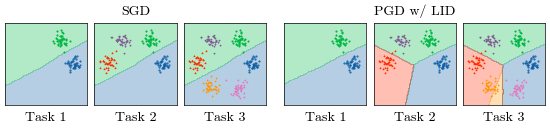

In [ ]:
interval_trainer.test(test_tasks, context_list=list(range(3)))
# interval_trainer.model[-1].set_context(0)
plot_results([trainer.model] * 3, [interval_trainer.model] * 3, test_tasks)

### Domain Incremental Training

In [41]:
train_tasks, val_tasks, test_tasks = get_mnist_tasks(seed=0)

model = models.get_mnist_model(seed=0)

print(
    f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
)

Tasks: [[7, 8], [0, 9], [1, 2], [3, 6], [4, 5]]


In [42]:
def domain_map_fn(labels: torch.Tensor) -> torch.Tensor:
    """Map the global label to the in context label."""
    return labels % 2

In [ ]:
l2_reg = L2Regulariser(lmbd=0.01)
ubias_reg = UnbiasRegulariser(lmbd=0.01)
regulariser = MultiRegulariser([l2_reg, ubias_reg])

trainer = SimpleTrainer(model)
trainer.train(
    train_tasks[0],
    val_tasks[0],
    epochs=5,
    batch_size=64,
    domain_map_fn=domain_map_fn,
    lr=0.027,
    regulariser=regulariser,
)
trainer.test(test_tasks[0:1], domain_map_fn=domain_map_fn, regulariser=regulariser)

Training Epochs: 100%|██████████| 5/5 [01:31<00:00, 18.34s/it, val_loss=0.674, val_acc=0.993]


Test Results: [(0.0196, 0.9938)]


In [46]:
interval_trainer = IntervalTrainer(
    trainer.model,
    checkpoint=20,
    n_iters=200,
    min_acc_limit=0.9,
    primal_learning_rate=0.33,
    dual_learning_rate=0.01,
    batch_size=400,
    paradigm="DIL",
)

# Compute bounds for task 0
interval_trainer.compute_rashomon_set(test_tasks[0], domain_map_fn=domain_map_fn)

for i, (train, val, test) in enumerate(
    zip(train_tasks[1:2], val_tasks[1:2], test_tasks[1:2])
):
    interval_trainer.train(train, val, batch_size=256, domain_map_fn=domain_map_fn)
    interval_trainer.test(test_tasks[0 : i + 2], domain_map_fn=domain_map_fn)
    # if i < len(train_tasks) - 2:
    #     interval_trainer.compute_rashomon_set(test, domain_map_fn=domain_map_fn)

---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.0922 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.90
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.99,  Min acc soft=0.99


100%|██████████| 200/200 [02:01<00:00,  1.64it/s, size=1030.60, obj=0.167, min_soft_acc=0.840]


Final bbox:  Obj=0.17,  Size=1030.60,  Min acc hard=0.84,  Min acc soft=0.84
Computing final certificates over 256 samples
Checkpointed every 20 iterations for a total of 10 checkpoints
Checkpoints sizes: ['37.80', '195.95', '436.91', '623.17', '783.82', '902.79', '963.39', '1001.66', '1021.78', '1030.60']
Checkpoint certificates: ['0.87', '0.86', '0.84', '0.88', '0.86', '0.85', '0.85', '0.85', '0.84', '0.84']
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|██████████| 5/5 [01:16<00:00, 15.35s/it, loss=0.1052, val_acc=0.9737, proj=2]


Test Results: [(0.0627, 0.9814), (0.0951, 0.9741)]


### Class Incremental Learning

In [ ]:
train_tasks, val_tasks, test_tasks = get_mnist_tasks()

model = models.get_mnist_model()

print(
    f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
)

Tasks: [[3, 4], [8, 9], [6, 7], [0, 5], [1, 2]]


In [11]:
trainer = SimpleTrainer(model)
trainer.train(train_tasks[0], val_tasks[0], epochs=3, batch_size=256)
trainer.test(test_tasks[0:1])

Training Epochs: 100%|██████████| 3/3 [00:47<00:00, 15.67s/it, val_loss=0.0131, val_acc=0.996]


Test Results: [(0.0141, 0.9959)]


In [12]:
interval_trainer = IntervalTrainer(
    trainer.model,
    checkpoint=20,
    n_iters=300,
    min_acc_limit=0.8,
    primal_learning_rate=0.5,
    paradigm="CIL",
)

# Compute bounds for task 0
interval_trainer.compute_rashomon_set(test_tasks[0])

for i, (train, val, test) in enumerate(
    zip(train_tasks[1:], val_tasks[1:], test_tasks[1:])
):
    interval_trainer.train(train, val, batch_size=256)
    interval_trainer.test(test_tasks[0 : i + 2])
    if i < len(train_tasks) - 2:
        interval_trainer.compute_rashomon_set(test)

---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.1961 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


100%|██████████| 300/300 [00:35<00:00,  8.37it/s, size=2292.68, obj=0.370, min_soft_acc=0.800]


Final bbox:  Obj=0.37,  Size=2292.68,  Min acc hard=0.81,  Min acc soft=0.81
Computing final certificates over 256 samples
Checkpointed every 20 iterations for a total of 15 checkpoints
Checkpoints sizes: ['47.00', '267.55', '507.62', '668.46', '842.55', '1013.38', '1160.04', '1306.64', '1433.29', '1599.27', '1756.46', '1920.88', '2020.43', '2180.30', '2292.68']
Checkpoint certificates: ['0.92', '0.89', '0.82', '0.87', '0.88', '0.83', '0.82', '0.82', '0.84', '0.79', '0.83', '0.75', '0.80', '0.80', '0.81']
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|██████████| 5/5 [01:19<00:00, 15.81s/it, loss=13.3160, val_acc=0.0000, proj=1]


Test Results: [(0.0147, 0.9956), (12.9738, 0.0)]
---------------------------- Computing Rashomon set ----------------------------


...

Test Results: [(0.0147, 0.9956), (27.9834, 0.0), (13.1664, 0.0)]
---------------------------- Computing Rashomon set ----------------------------


Training Epochs: 100%|██████████| 5/5 [01:18<00:00, 15.77s/it, loss=14.1831, val_acc=0.0000, proj=0]


Test Results: [(0.0147, 0.9956), (41.3093, 0.0), (26.9544, 0.0), (14.8332, 0.0)]
---------------------------- Computing Rashomon set ----------------------------


Training Epochs: 100%|██████████| 5/5 [01:17<00:00, 15.60s/it, loss=11.7589, val_acc=0.0000, proj=0]


Test Results: [(0.0147, 0.9956), (51.1031, 0.0), (45.7826, 0.0), (35.8907, 0.0), (12.1649, 0.0)]


### Class Incremental Learning + Regulariser

In [13]:
train_tasks, val_tasks, test_tasks = get_mnist_tasks()

model = models.get_mnist_model()

print(
    f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
)

Tasks: [[3, 4], [8, 9], [6, 7], [0, 5], [1, 2]]


In [ ]:
regulariser = UnbiasRegulariser(lmbd=0.01)

trainer = SimpleTrainer(model)
trainer.train(
    train_tasks[0], val_tasks[0], epochs=3, batch_size=256, regulariser=regulariser
)
trainer.test(test_tasks[0:1])

Training Epochs: 100%|██████████| 3/3 [00:53<00:00, 17.89s/it, val_loss=2.08, val_acc=0.996]


Test Results: [(0.0141, 0.9959)]


In [19]:
interval_trainer = IntervalTrainer(
    trainer.model,
    checkpoint=20,
    n_iters=300,
    min_acc_limit=0.8,
    primal_learning_rate=0.5,
    paradigm="CIL",
)

# Compute bounds for task 0
interval_trainer.compute_rashomon_set(test_tasks[0])

for i, (train, val, test) in enumerate(
    zip(train_tasks[1:], val_tasks[1:], test_tasks[1:])
):
    interval_trainer.train(train, val, batch_size=256, regulariser=regulariser)
    interval_trainer.test(test_tasks[0 : i + 2])
    if i < len(train_tasks) - 2:
        interval_trainer.compute_rashomon_set(test)

---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.1961 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


100%|██████████| 300/300 [00:35<00:00,  8.38it/s, size=2292.68, obj=0.370, min_soft_acc=0.800]


Final bbox:  Obj=0.37,  Size=2292.68,  Min acc hard=0.81,  Min acc soft=0.81
Computing final certificates over 256 samples
Checkpointed every 20 iterations for a total of 15 checkpoints
Checkpoints sizes: ['47.00', '267.55', '507.62', '668.46', '842.55', '1013.38', '1160.04', '1306.64', '1433.29', '1599.27', '1756.46', '1920.88', '2020.43', '2180.30', '2292.68']
Checkpoint certificates: ['0.92', '0.89', '0.82', '0.87', '0.88', '0.83', '0.82', '0.82', '0.84', '0.79', '0.83', '0.75', '0.80', '0.80', '0.81']
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|██████████| 5/5 [01:34<00:00, 18.82s/it, loss=14.4256, val_acc=0.0000, proj=1]


Test Results: [(0.0147, 0.9956), (12.9738, 0.0)]
---------------------------- Computing Rashomon set ----------------------------


...

Test Results: [(0.0147, 0.9956), (27.9834, 0.0), (13.1664, 0.0)]
---------------------------- Computing Rashomon set ----------------------------


Training Epochs: 100%|██████████| 5/5 [01:30<00:00, 18.06s/it, loss=15.2460, val_acc=0.0000, proj=0]


Test Results: [(0.0147, 0.9956), (41.3093, 0.0), (26.9544, 0.0), (14.8332, 0.0)]
---------------------------- Computing Rashomon set ----------------------------


Training Epochs: 100%|██████████| 5/5 [17:04<00:00, 204.90s/it, loss=12.4792, val_acc=0.0000, proj=0]  


Test Results: [(0.0147, 0.9956), (51.1031, 0.0), (45.7826, 0.0), (35.8907, 0.0), (12.1649, 0.0)]
